# Part 2: RFM Segmentation & Retention Strategy

Author: Apurva Jain

Objective:
Build customer segments using RFM analysis and additional behavioral signals to recommend targeted retention actions.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
tickets = pd.read_csv("support_tickets.csv")
web = pd.read_csv("web_events_snapshot.csv")
interventions = pd.read_csv("intervention_history.csv")

In [4]:
orders["order_date"] = pd.to_datetime(
    orders["order_date"]
)

orders_pre = orders[
    orders["order_date"] <= "2025-09-30"
]

print(orders_pre.shape)

(8137, 10)


In [5]:
snapshot_date = pd.Timestamp("2025-09-30")

In [6]:
recency = (
    orders_pre
    .groupby("customer_id")["order_date"]
    .max()
    .reset_index()
)

recency["recency_days"] = (
    snapshot_date - recency["order_date"]
).dt.days

In [7]:
frequency = (
    orders_pre
    .groupby("customer_id")
    .size()
    .reset_index(name="frequency")
)

In [8]:
monetary = (
    orders_pre
    .groupby("customer_id")["gross_amount"]
    .sum()
    .reset_index(name="monetary")
)

In [9]:
rfm = recency.merge(
    frequency,
    on="customer_id"
)

rfm = rfm.merge(
    monetary,
    on="customer_id"
)

rfm.head()

,customer_id,order_date,recency_days,frequency,monetary
0,CUST00001,2025-06-15,107,6,2955.57
1,CUST00002,2025-08-21,40,1,581.00
2,CUST00003,2025-04-12,171,1,649.98
3,CUST00004,2025-05-22,131,1,1604.04
4,CUST00005,2025-08-23,38,4,2550.91


In [13]:

# Recency Score
rfm["R_score"] = pd.qcut(
    rfm["recency_days"],
    5,
    labels=[5,4,3,2,1]
).astype(int)

# Frequency Score
rfm["F_score"] = pd.cut(
    rfm["frequency"],
    bins=5,
    labels=[1,2,3,4,5]
).astype(int)

# Monetary Score
rfm["M_score"] = pd.qcut(
    rfm["monetary"],
    5,
    labels=[1,2,3,4,5]
).astype(int)

# Total Score
rfm["RFM_score"] = (
    rfm["R_score"] +
    rfm["F_score"] +
    rfm["M_score"]
)

rfm.head()

,customer_id,order_date,recency_days,frequency,monetary,R_score,F_score,M_score,RFM_score
0,CUST00001,2025-06-15,107,6,2955.57,2,2,4,8
1,CUST00002,2025-08-21,40,1,581.00,4,1,1,6
2,CUST00003,2025-04-12,171,1,649.98,1,1,1,3
3,CUST00004,2025-05-22,131,1,1604.04,2,1,3,6
4,CUST00005,2025-08-23,38,4,2550.91,4,1,3,8


In [12]:
rfm["frequency"].value_counts().sort_index()

,count
frequency,
1,696
2,380
3,348
4,311
5,217
6,162
7,118
8,83
9,35


Customer Segments

In [14]:
def segment_customer(score):

    if score >= 13:
        return "Champions"

    elif score >= 10:
        return "Loyal Customers"

    elif score >= 8:
        return "Potential Loyalists"

    elif score >= 6:
        return "At Risk"

    else:
        return "Lost Customers"


rfm["segment"] = rfm["RFM_score"].apply(segment_customer)

rfm["segment"].value_counts()

,count
segment,
At Risk,735
Potential Loyalists,612
Lost Customers,582
Loyal Customers,416
Champions,55


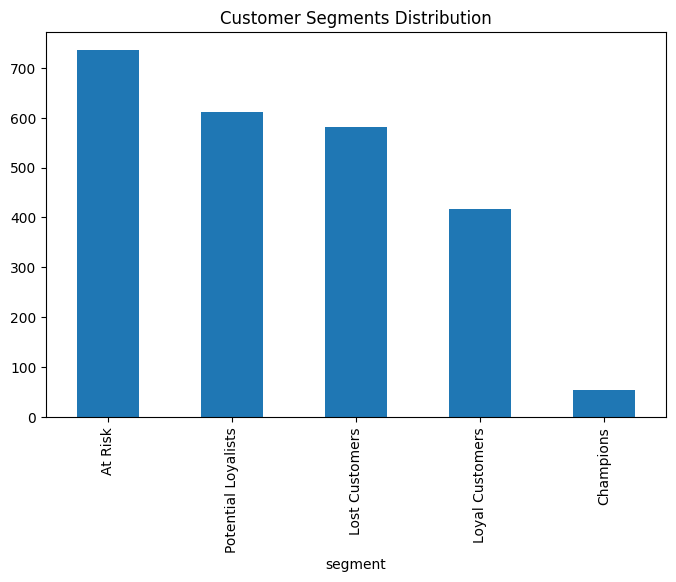

In [15]:
plt.figure(figsize=(8,5))

rfm["segment"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Segments Distribution")
plt.show()

Observation:

Customers are distributed across multiple RFM-based segments.
The segmentation highlights both high-value customers and potentially vulnerable customer groups requiring retention interventions.

In [16]:
rfm.to_csv(
    "segments.csv",
    index=False
)

print("segments.csv created")

segments.csv created


## Segment Insights

### Segment Summary

- Champions (55): Most valuable customers with high recency, frequency, and monetary scores.
- Loyal Customers (416): Consistent purchasers with strong engagement patterns.
- Potential Loyalists (612): Customers showing positive behavior but not yet top-tier customers.
- At Risk (735): Customers with declining engagement and lower recent activity.
- Lost Customers (582): Customers showing weak recent activity and lower overall value.

Observation:

The largest segment consists of At Risk customers, suggesting a significant opportunity for targeted retention efforts.